In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [13]:
X, y = make_blobs(n_samples=100, centers=[(0,1),(1,0)], n_features=2, cluster_std=0.25)
clf = svm.SVC(kernel='linear')
clf.fit(X, y)
y_pred = clf.predict(X)
accuracy_score(y_pred,y)

1.0

In [19]:
X, y = make_blobs(n_samples=100, centers=[(0,1),(1,0)], n_features=2, cluster_std=0.5)
clf = svm.SVC(kernel='linear')
clf.fit(X, y)
y_pred = clf.predict(X)
accuracy_score(y_pred,y)

0.9

In [22]:
X, y = make_moons(n_samples=100, noise=0.2, random_state=5)
clf = svm.SVC()
clf.fit(X, y)
y_pred = clf.predict(X)
accuracy_score(y_pred,y)

0.95

In [44]:
X, y = make_circles(n_samples=100, noise=0.2, factor=0.3, random_state=5)
clf = svm.SVC()
clf.fit(X, y)
y_pred = clf.predict(X)
accuracy_score(y_pred,y)

0.95

In [34]:
X, y = make_moons(n_samples=100, noise=0.2, random_state=5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
clf = svm.SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)
print(accuracy_score(y_pred,y_train))
yt_pred = clf.predict(X_test)
print(accuracy_score(yt_pred,y_test))

0.925
1.0


<ipython-input-36-4c8c73745724>:25: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(XX, YY, Z, cmap=plt.cm.Pastel1)


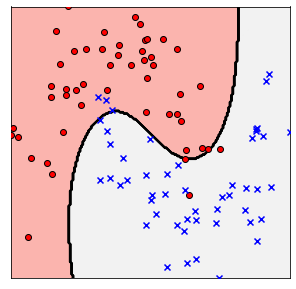

In [36]:
fig=plt.figure(1, figsize=(5, 5))
plt.clf()

markers = ['o', 'x', ',', '^', 'v', '*', '+', 'D']
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
m = 0
for i in set(y):
    n = np.where(y==i)
    plt.scatter(X[n, 0], X[n, 1], marker=markers[m], c=colors[m], zorder=10, edgecolors='k')
    m=m+1

plt.axis('tight')
x_min = min(X[:,0])
x_max = max(X[:,0])
y_min = min(X[:,1])
y_max = max(X[:,1])

XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
#Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
Z = clf.predict(np.c_[XX.ravel(), YY.ravel()])

# Put the result into a color plot
Z = Z.reshape(XX.shape)

plt.pcolormesh(XX, YY, Z, cmap=plt.cm.Pastel1)
plt.contour(XX, YY, Z, colors='k')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xticks(())
plt.yticks(())

plt.show()
fig.savefig("img.png")
fig.savefig("img.pdf")